# 01 — Слой продаж: от строк base.xlsx к заказам

Задача 1 кейса: разобраться, что в данных на самом деле, и зафиксировать определения,
на которые дальше опирается вся attribution-логика.

Ноутбук делает четыре вещи:

1. проверяет, что `Сумма` в файле означает не то, что кажется на первый взгляд;
2. на основе этой проверки определяет заказ, покупателя и выручку;
3. показывает динамику продаж и разбирает три всплеска — у них разная природа;
4. выгружает `orders.csv` / `order_items.csv` / `daily.csv` как вход для attribution.

Все выводы ниже получены из `base.xlsx` и ничем не дополнены. Там, где данных не хватает,
это написано прямо, а не закрыто моделью.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

plt.rcParams.update({
    "figure.figsize": (11, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# ноутбук лежит в notebooks/, данные — в data/; работает и из корня репозитория
CANDIDATES = [Path("../data/base.xlsx"), Path("data/base.xlsx"), Path("base.xlsx")]
DATA = next(p for p in CANDIDATES if p.exists())
OUT = DATA.parent.parent / "outputs"
OUT.mkdir(exist_ok=True)

print("данные:", DATA.resolve())

данные: /home/claude/postupashki/data/base.xlsx


## 1. Сырой слой

Четыре колонки, русские названия. Сразу переименуем в латиницу, чтобы дальше не мучиться,
и посмотрим, что вообще пришло.

In [2]:
raw = pd.read_excel(DATA)
print("исходные колонки:", list(raw.columns))

raw = raw.rename(columns={
    "Номер студента": "student_id",
    "Сумма": "amount",
    "Курс": "course",
    "Время": "ts",
})
raw["ts"] = pd.to_datetime(raw["ts"])
raw["date"] = raw["ts"].dt.date

print(f"\nстрок: {len(raw)}")
print(f"период: {raw.ts.min()} — {raw.ts.max()}")
print(f"уникальных student_id: {raw.student_id.nunique()}")
print(f"уникальных курсов: {raw.course.nunique()}")
print(f"уникальных timestamp: {raw.ts.nunique()}")
raw.head(10)

исходные колонки: ['Номер студента', 'Сумма', 'Курс', 'Время']

строк: 795
период: 2026-08-04 09:08:31 — 2026-09-10 06:09:12
уникальных student_id: 606
уникальных курсов: 18
уникальных timestamp: 627


,student_id,amount,course,ts,date
0,437,8950.0,ML про,2026-08-04 09:08:31,2026-08-04
1,437,7890.0,Аналитика старт,2026-08-04 09:35:00,2026-08-04
2,443,8475.0,Линейная алгебра,2026-08-04 10:14:38,2026-08-04
3,443,8475.0,Мат анализ,2026-08-04 10:14:38,2026-08-04
4,430,8950.0,К ВУЗу,2026-08-04 13:38:06,2026-08-04
5,480,15695.0,Data Science,2026-08-04 16:17:19,2026-08-04
6,131,8745.0,Backend старт,2026-08-04 17:05:46,2026-08-04
7,571,8475.0,ML про,2026-08-04 17:19:52,2026-08-04
8,571,8475.0,ML старт,2026-08-04 17:19:52,2026-08-04
9,159,8475.0,Backend про,2026-08-05 12:56:32,2026-08-05


In [3]:
# качество: пропуски, полные дубликаты, отрицательные суммы
print("пропуски:\n", raw.isna().sum().to_string())
print("\nполных дубликатов строк:", raw.duplicated().sum())
print("сумм <= 0:", (raw.amount <= 0).sum())
print("\nодин и тот же курс куплен одним студентом дважды:",
      raw.duplicated(["student_id", "course"]).sum(), "случая")

пропуски:
 student_id    0
amount        0
course        0
ts            0
date          0

полных дубликатов строк: 0
сумм <= 0: 0

один и тот же курс куплен одним студентом дважды: 3 случая


Пропусков нет, дубликатов строк нет. Три случая, когда один студент числится купившим
один и тот же курс дважды — это не мусор, а повторные покупки в разные даты; ниже видно, что
timestamp у них разный.

Первое, что бросается в глаза: **795 строк, но только 627 уникальных timestamp**. Значит часть
строк делит момент времени — это те самые пакеты, о которых предупреждают организаторы.

In [4]:
dup_ts = raw[raw.duplicated("ts", keep=False)].sort_values("ts")
dup_ts.head(12)

,student_id,amount,course,ts,date
2,443,8475.0,Линейная алгебра,2026-08-04 10:14:38,2026-08-04
3,443,8475.0,Мат анализ,2026-08-04 10:14:38,2026-08-04
7,571,8475.0,ML про,2026-08-04 17:19:52,2026-08-04
8,571,8475.0,ML старт,2026-08-04 17:19:52,2026-08-04
9,159,8475.0,Backend про,2026-08-05 12:56:32,2026-08-05
10,159,8475.0,Backend старт,2026-08-05 12:56:32,2026-08-05
15,222,7975.0,Backend про,2026-08-05 18:52:56,2026-08-05
16,222,7975.0,Backend старт,2026-08-05 18:52:56,2026-08-05
18,291,9950.0,Мат анализ,2026-08-06 10:06:16,2026-08-06
17,291,9950.0,Линейная алгебра,2026-08-06 10:06:16,2026-08-06


## 2. Что такое `Сумма` на самом деле

Здесь легко ошибиться. Кажется, что `amount` — цена курса. Но посмотрим на характерные значения:
`2237.5`, `5463.33`, `5463.34`, `8475`. Это не прайс-лист, это результат деления.

Гипотеза: **`amount` — это уже разнесённая доля заказа, а не цена курса**. Заказ делится поровну
между купленными курсами, с копеечным округлением на последнюю строку.

Проверяется она в одну строчку: если гипотеза верна, внутри каждого многострочного заказа
все доли должны совпадать, а их сумма — давать «круглый» прайс-поинт.

In [5]:
g = raw.groupby(["student_id", "ts"])["amount"].agg(["size", "min", "max", "sum"])
multi = g[g["size"] > 1]
unequal = multi[(multi["max"] - multi["min"]) > 0.02]

print(f"многострочных заказов: {len(multi)}")
print(f"из них с НЕравными долями: {len(unequal)}")

многострочных заказов: 153
из них с НЕравными долями: 0


In [6]:
# суммы многострочных заказов — это и есть цены пакетов
print("топ сумм по многострочным заказам:\n")
print(multi["sum"].round(2).value_counts().sort_values(ascending=False).head(12).to_string())

топ сумм по многострочным заказам:

sum
14950.0    56
9900.0     24
13950.0    15
9990.0     14
16950.0     9
8990.0      2
17950.0     2
12950.0     2
8950.0      2
19900.0     2
11950.0     2
8900.0      2


Ни одного заказа с неравными долями из 153. А суммы — ровно те прайс-поинты, которые
организаторы упоминают в условии: 9 990, 14 950, 13 950, 16 950, 9 900.

Крайний случай, который окончательно закрывает вопрос: пакет из четырёх курсов за 8 950 ₽ —
четыре строки по 2 237.5.

In [7]:
sizes = g["size"].value_counts().sort_index()
print("курсов в заказе → сколько таких заказов:\n", sizes.to_string())

big = g[g["size"] >= 4].index[0]
print("\nпример пакета из 4 курсов:")
raw[(raw.student_id == big[0]) & (raw.ts == big[1])]

курсов в заказе → сколько таких заказов:
 size
1    475
2    145
3      4
4      2
5      2

пример пакета из 4 курсов:


,student_id,amount,course,ts,date
788,36,8950.0,Алгоритмы,2026-09-09 19:26:20,2026-09-09
789,36,8950.0,Дискретка,2026-09-09 19:26:20,2026-09-09
790,36,8950.0,Линейная алгебра,2026-09-09 19:26:20,2026-09-09
791,36,8950.0,Мат анализ,2026-09-09 19:26:20,2026-09-09
792,36,8950.0,Теория вероятностей,2026-09-09 19:26:20,2026-09-09


### Определения, которые отсюда следуют

Их нужно защищать на презентации, поэтому формулируем явно:

| Сущность | Определение | Обоснование |
|---|---|---|
| **Заказ** | покупки одного `student_id` в пределах сессии (разрыв < 24 ч) | доступ выдаётся в момент оплаты, но покупка может растянуться на несколько транзакций |
| **Позиция заказа** | строка файла | один курс внутри заказа |
| **Выручка заказа** | сумма `amount` по позициям | доли уже разнесены, складывать корректно |
| **Покупатель** | `student_id` | обезличенный хеш от Telegram-username |
| **Цена курса** | наблюдаема только в заказах из одного курса | в пакетах цена отдельного курса не существует, есть только доля |

Последняя строка важна для любого анализа цен: медиану цены имеет смысл считать **только
по одиночным заказам**, иначе пакеты занижают её механически.

### Оговорка: точного совпадения timestamp недостаточно

Если считать заказом строгое равенство `timestamp`, часть покупок разваливается на две.
Пример: студент 437 оплачивает в 09:08:31 и в 09:35:00 — человек вернулся в переписку
с менеджером и дописал ещё курс, а время разошлось на 27 минут.

Поэтому заказ определяется через **сессию**: покупки одного студента, между которыми
прошло меньше `SESSION_HOURS`. Порог — допущение, и его стоит держать на виду.

In [8]:
SESSION_HOURS = 24   # ДОПУЩЕНИЕ: разрыв больше суток = новое решение о покупке

order_items = raw.sort_values(["student_id", "ts"]).reset_index(drop=True)
gap = order_items.groupby("student_id").ts.diff()
order_items["new_session"] = gap.isna() | (gap > pd.Timedelta(hours=SESSION_HOURS))
order_items["session_no"] = order_items.groupby("student_id").new_session.cumsum()

orders = (
    order_items.groupby(["student_id", "session_no"])
    .agg(ts=("ts", "min"), ts_last=("ts", "max"), revenue=("amount", "sum"),
         n_items=("course", "size"),
         courses=("course", lambda s: " + ".join(sorted(s))))
    .reset_index()
    .sort_values("ts")
    .reset_index(drop=True)
)
orders["order_id"] = [f"O{i + 1:04d}" for i in range(len(orders))]
orders["date"] = orders["ts"].dt.date

order_items = order_items.merge(
    orders[["student_id", "session_no", "order_id"]], on=["student_id", "session_no"]
)

exact_ts = raw.groupby(["student_id", "ts"]).ngroups
print(f"{len(raw)} строк")
print(f"заказов при строгом совпадении timestamp: {exact_ts}")
print(f"заказов при сессии в {SESSION_HOURS} ч:      {len(orders)}")
print(f"склеено покупок: {exact_ts - len(orders)}")
orders.head(8)

795 строк
заказов при строгом совпадении timestamp: 628
заказов при сессии в 24 ч:      625
склеено покупок: 3


,student_id,session_no,ts,ts_last,revenue,n_items,courses,order_id,date
0,437,1,2026-08-04 09:08:31,2026-08-04 09:35:00,16840.0,2,ML про + Аналитика старт,O0001,2026-08-04
1,443,1,2026-08-04 10:14:38,2026-08-04 10:14:38,16950.0,2,Линейная алгебра + Мат анализ,O0002,2026-08-04
2,430,1,2026-08-04 13:38:06,2026-08-04 13:38:06,8950.0,1,К ВУЗу,O0003,2026-08-04
3,480,1,2026-08-04 16:17:19,2026-08-04 16:17:19,15695.0,1,Data Science,O0004,2026-08-04
4,131,1,2026-08-04 17:05:46,2026-08-04 17:05:46,8745.0,1,Backend старт,O0005,2026-08-04
5,571,1,2026-08-04 17:19:52,2026-08-04 17:19:52,16950.0,2,ML про + ML старт,O0006,2026-08-04
6,159,1,2026-08-05 12:56:32,2026-08-05 12:56:32,16950.0,2,Backend про + Backend старт,O0007,2026-08-05
7,126,1,2026-08-05 13:22:41,2026-08-05 13:22:41,8745.0,1,ML старт,O0008,2026-08-05


### Первые и повторные заказы

Разделение, без которого attribution даст неверный ответ. Повторная покупка — это выручка
с уже привлечённого клиента, и приписывать её платному размещению нельзя: за этого человека
уже заплатили один раз. В терминах кейса это граница между acquisition и retention.

In [9]:
orders["seq"] = orders.groupby("student_id").cumcount() + 1
orders["is_repeat"] = orders["seq"] > 1

rep = orders[orders.is_repeat]
print(f"повторных заказов: {len(rep)} на "
      f"{rep.revenue.sum():,.0f} ₽".replace(",", " "))
print(f"доля выручки: {rep.revenue.sum() / orders.revenue.sum():.1%}")

first_ts = orders[~orders.is_repeat].set_index("student_id").ts
gap_days = (rep.ts - rep.student_id.map(first_ts)).dt.total_seconds() / 86400
print(f"разрыв до первой покупки, дней: медиана {gap_days.median():.1f}, "
      f"min {gap_days.min():.1f}, max {gap_days.max():.1f}")

повторных заказов: 19 на 164 140 ₽
доля выручки: 2.8%
разрыв до первой покупки, дней: медиана 18.0, min 1.4, max 28.5


## 3. Базовые метрики

Ничего сложного, но эти цифры пойдут на первый слайд, поэтому считаем их один раз и здесь.

In [10]:
def rub(x):
    # 5904671.67 -> '5 904 672 ₽', пробел как разделитель разрядов
    return f"{x:,.0f} ₽".replace(",", " ")


revenue = orders.revenue.sum()
n_orders = len(orders)
n_customers = orders.student_id.nunique()

print(f"выручка за период      {rub(revenue)}")
print(f"заказов                {n_orders}")
print(f"покупателей            {n_customers}")
print(f"средний чек (AOV)      {rub(revenue / n_orders)}")
print(f"выручка на покупателя  {rub(revenue / n_customers)}")
print(f"курсов в заказе        {order_items.shape[0] / n_orders:.2f} в среднем")

выручка за период      5 904 672 ₽
заказов                625
покупателей            606
средний чек (AOV)      9 447 ₽
выручка на покупателя  9 744 ₽
курсов в заказе        1.27 в среднем


In [11]:
per_customer = orders.groupby("student_id").size()
repeat = (per_customer > 1).sum()

print("заказов на покупателя:\n", per_customer.value_counts().sort_index().to_string())
print(f"\nповторных покупателей: {repeat} из {n_customers} ({repeat / n_customers:.1%})")

заказов на покупателя:
 1    588
2     17
3      1

повторных покупателей: 18 из 606 (3.0%)


**Повторных покупателей около 3% за пять недель.** Это не ошибка данных и не «мало времени» —
это факт, у которого есть прямые последствия для остальной части решения:

- LTV как метрика для распределения бюджета здесь бессмысленна, считать надо по первой покупке;
- в attribution не нужна сложная логика повторных конверсий — их почти нет;
- `ROMI` по платным размещениям считается на выручке первых заказов; повторные в него не входят.

Оговорка: история начинается 4 августа, покупки до этой даты не видны. Поэтому 3.3% — это
нижняя оценка доли повторных, а не итоговый retention.

## 4. Продукты

18 курсов. Смотрим не только выручку, но и дату первой продажи — она понадобится ниже,
чтобы отличить запуск продукта от рекламного всплеска.

In [12]:
prod = (
    order_items.groupby("course")
    .agg(revenue=("amount", "sum"), items=("amount", "size"),
         first_sale=("ts", "min"), buyers=("student_id", "nunique"))
    .sort_values("revenue", ascending=False)
)
prod["share"] = (prod.revenue / prod.revenue.sum() * 100).round(1)
prod

,revenue,items,first_sale,buyers,share
course,,,,,
Аналитика про,740941.50,93,2026-08-08 16:22:47,92,12.5
ML про,715110.00,90,2026-08-04 09:08:31,90,12.1
AI агенты,711673.00,91,2026-08-22 08:23:59,90,12.1
Аналитика старт,641616.50,91,2026-08-04 09:35:00,91,10.9
Алгоритмы старт,529851.68,88,2026-08-08 12:24:55,88,9.0
ML старт,523278.33,80,2026-08-04 17:19:52,80,8.9
Backend про,438342.50,55,2026-08-05 12:56:32,55,7.4
Алгоритмы про,268409.00,35,2026-08-12 05:32:11,35,4.5
Backend старт,263396.66,39,2026-08-04 17:05:46,39,4.5


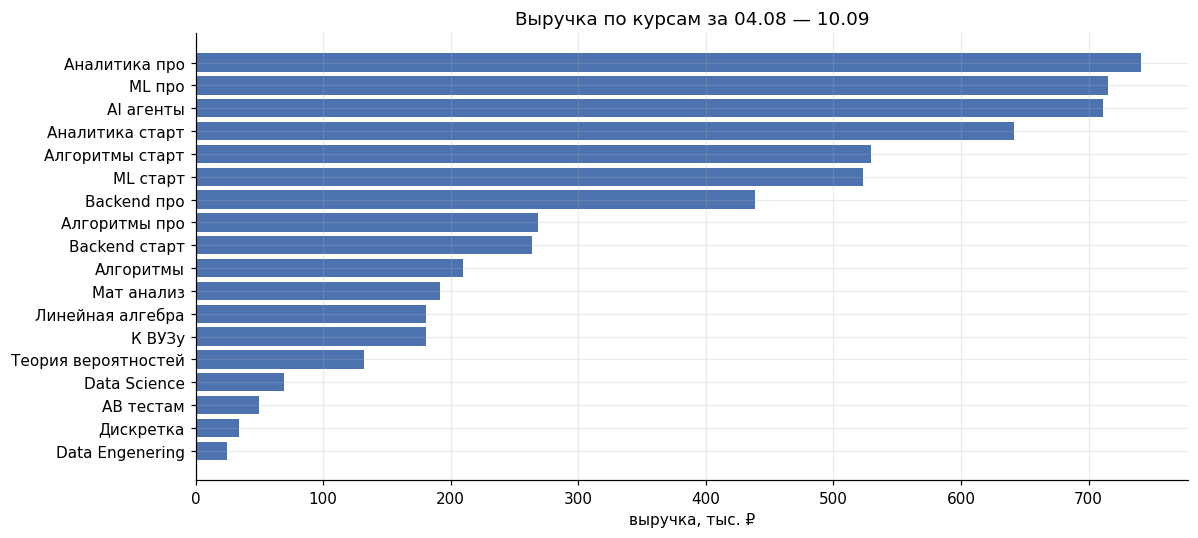

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
p = prod.sort_values("revenue")
ax.barh(p.index, p.revenue / 1000, color="#4C72B0")
ax.set_xlabel("выручка, тыс. ₽")
ax.set_title("Выручка по курсам за 04.08 — 10.09")
plt.tight_layout()
plt.show()

In [14]:
launches = prod.sort_values("first_sale")[["first_sale", "revenue", "items"]]
print("даты первых продаж — кандидаты в даты запуска:\n")
print(launches.to_string())

даты первых продаж — кандидаты в даты запуска:

                             first_sale    revenue  items
course                                                   
ML про              2026-08-04 09:08:31  715110.00     90
Аналитика старт     2026-08-04 09:35:00  641616.50     91
Мат анализ          2026-08-04 10:14:38  191382.50     20
Линейная алгебра    2026-08-04 10:14:38  180665.00     19
К ВУЗу              2026-08-04 13:38:06  180250.00     26
Data Science        2026-08-04 16:17:19   69295.00      9
Backend старт       2026-08-04 17:05:46  263396.66     39
ML старт            2026-08-04 17:19:52  523278.33     80
Backend про         2026-08-05 12:56:32  438342.50     55
АВ тестам           2026-08-05 14:22:34   49610.00      8
Теория вероятностей 2026-08-06 14:52:49  132107.50     13
Алгоритмы старт     2026-08-08 12:24:55  529851.68     88
Алгоритмы           2026-08-08 13:57:16  209482.50     30
Аналитика про       2026-08-08 16:22:47  740941.50     93
Data Engenering     2026

Восемь курсов продаются с первого дня — это существующая линейка. А дальше видны
три момента, когда в каталоге появляется что-то новое:

- **8 августа** — сразу четыре курса: Алгоритмы старт, Алгоритмы, Аналитика про, Data Engenering;
- **22 августа** — AI агенты;
- **31 августа** — Дискретка.

Первые две даты совпадают с двумя из трёх всплесков продаж. Это не совпадение и это сильно
меняет интерпретацию — см. раздел 6.

## 5. Динамика

Сначала техническая деталь, которая иначе испортит все графики и бэктесты.

In [15]:
last_day = orders[orders.date == orders.date.max()]
print("последний день в данных:")
print(last_day[["order_id", "ts", "revenue"]].to_string(index=False))

последний день в данных:
order_id                  ts  revenue
   O0625 2026-09-10 06:09:12   9950.0


10 сентября — **один заказ в 06:09**. День обрезан на середине выгрузки, это не падение спроса.
Везде дальше он исключается из трендов; для прогноза и бэктеста его тоже надо выкидывать,
иначе модель будет учиться на артефакте.

In [16]:
daily = (
    orders.groupby("date")
    .agg(orders=("order_id", "size"), revenue=("revenue", "sum"),
         customers=("student_id", "nunique"))
    .reset_index()
)
daily["date"] = pd.to_datetime(daily["date"])
daily["dow"] = daily["date"].dt.dayofweek
daily["is_weekend"] = daily["dow"] >= 5

full = daily[daily.date < daily.date.max()].copy()   # без обрезанного 10.09
print(f"полных дней: {len(full)}")
full.head()

полных дней: 37


,date,orders,revenue,customers,dow,is_weekend
0,2026-08-04,6,84130.0,6,1,False
1,2026-08-05,6,67110.0,6,2,False
2,2026-08-06,7,62445.0,7,3,False
3,2026-08-07,5,54995.0,5,4,False
4,2026-08-08,35,275015.0,35,5,True


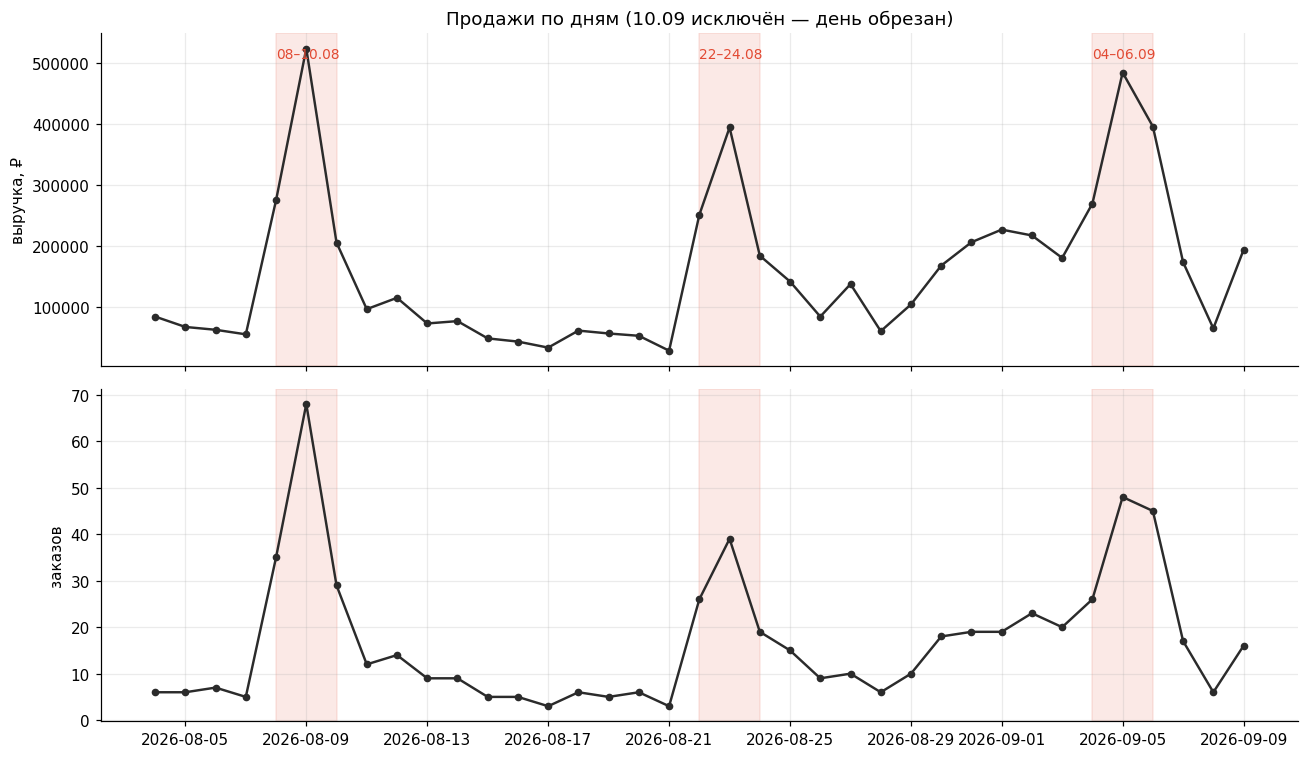

In [17]:
SPIKES = {
    "08–10.08": ("2026-08-08", "2026-08-10"),
    "22–24.08": ("2026-08-22", "2026-08-24"),
    "04–06.09": ("2026-09-04", "2026-09-06"),
}

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, col, lab in zip(axes, ["revenue", "orders"], ["выручка, ₽", "заказов"]):
    ax.plot(full.date, full[col], marker="o", ms=4, lw=1.6, color="#2b2b2b")
    for name, (a, b) in SPIKES.items():
        ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color="#E24A33", alpha=0.12)
    ax.set_ylabel(lab)

for name, (a, b) in SPIKES.items():
    axes[0].text(pd.Timestamp(a), full.revenue.max() * 0.97, name,
                 fontsize=9, color="#E24A33")

axes[0].set_title("Продажи по дням (10.09 исключён — день обрезан)")
plt.tight_layout()
plt.show()

In [18]:
base_level = full[~full.date.dt.strftime("%Y-%m-%d").isin(
    sum([list(pd.date_range(a, b).strftime("%Y-%m-%d")) for a, b in SPIKES.values()], [])
)]
print(f"фон вне всплесков: медиана {base_level.orders.median():.0f} заказов "
      f"({rub(base_level.revenue.median())}) в день")
print()

for name, (a, b) in SPIKES.items():
    w = full[(full.date >= a) & (full.date <= b)]
    print(f"{name}: {w.orders.sum():3d} заказов | {rub(w.revenue.sum()):>12} | "
          f"пик {w.orders.max()} заказов в день")

фон вне всплесков: медиана 9 заказов (80 382 ₽) в день

08–10.08: 132 заказов |  1 004 697 ₽ | пик 68 заказов в день
22–24.08:  84 заказов |    829 718 ₽ | пик 39 заказов в день
04–06.09: 119 заказов |  1 150 344 ₽ | пик 48 заказов в день


### Выходные

Прежде чем связывать всплески с рекламой, надо разобраться с сезонностью — иначе любой вывод
вида «после поста продажи выросли» будет объясняться днём недели.

    mean_orders  median_orders  n_days
Пн         17.4           19.0       5
Вт         10.7            9.0       6
Ср         12.2           11.5       6
Чт         10.4            9.0       5
Пт          9.8            6.0       5
Сб         24.8           26.0       5
Вс         35.0           39.0       5


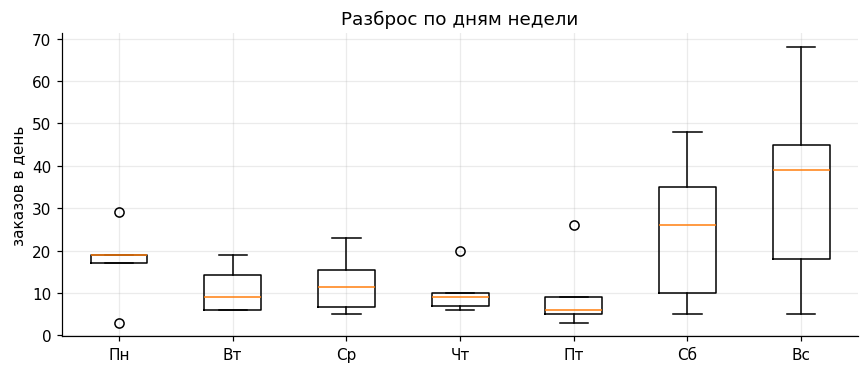

In [19]:
dow_names = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
by_dow = full.groupby("dow").agg(mean_orders=("orders", "mean"),
                                 median_orders=("orders", "median"),
                                 n_days=("orders", "size"))
by_dow.index = [dow_names[i] for i in by_dow.index]
print(by_dow.round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 3.5))
data = [full[full.dow == i].orders.values for i in range(7)]
ax.boxplot(data, labels=dow_names)
ax.set_ylabel("заказов в день")
ax.set_title("Разброс по дням недели")
plt.tight_layout()
plt.show()

Выходные заметно выше будней, но разброс огромный: в субботу бывает и 5 заказов, и 49.
Все три всплеска пришлись на Сб–Вс — **однако два других уик-энда (15–16 и 29–30 августа)
были совершенно обычными**.

Вывод, который отсюда можно защищать: выходные — усилитель, а не причина. Практическое
следствие для задачи 7: любая оценка эффекта рекламы (ITS, DiD, сравнение с baseline)
обязана контролировать день недели, иначе она измеряет календарь.

## 6. Три всплеска — три разные истории

Ключевой раздел. Общепринятая ошибка — сказать «были всплески, значит работала реклама».
Посмотрим на цены: если всплеск вызван скидкой, средний чек падает; если запуском или
внешним трафиком — нет.

Цены считаем по одиночным заказам, как договорились в разделе 2.

In [20]:
single = orders[orders.n_items == 1].merge(
    order_items[["order_id", "course"]], on="order_id"
)
single["date"] = pd.to_datetime(single["ts"].dt.date)

price = single.pivot_table(index="date", columns="course",
                           values="revenue", aggfunc="median")

watch = ["ML старт", "Аналитика старт", "Алгоритмы старт", "ML про", "Аналитика про"]
print(price[watch].loc["2026-08-04":"2026-08-20"].round(0).to_string())

course      ML старт  Аналитика старт  Алгоритмы старт  ML про  Аналитика про
date                                                                         
2026-08-04       NaN              NaN              NaN     NaN            NaN
2026-08-05    8495.0              NaN              NaN     NaN            NaN
2026-08-06    8245.0              NaN              NaN     NaN            NaN
2026-08-07       NaN              NaN              NaN  8745.0            NaN
2026-08-08    5990.0           6490.0           5742.0  8745.0            NaN
2026-08-09    6490.0           6490.0           5990.0  8745.0            NaN
2026-08-10    6490.0           6490.0           4950.0     NaN         4950.0
2026-08-11    4950.0           6490.0           4950.0     NaN            NaN
2026-08-12    6500.0           8745.0              NaN     NaN            NaN
2026-08-13    6000.0              NaN           8745.0     NaN         8610.0
2026-08-14       NaN              NaN           8745.0     NaN  

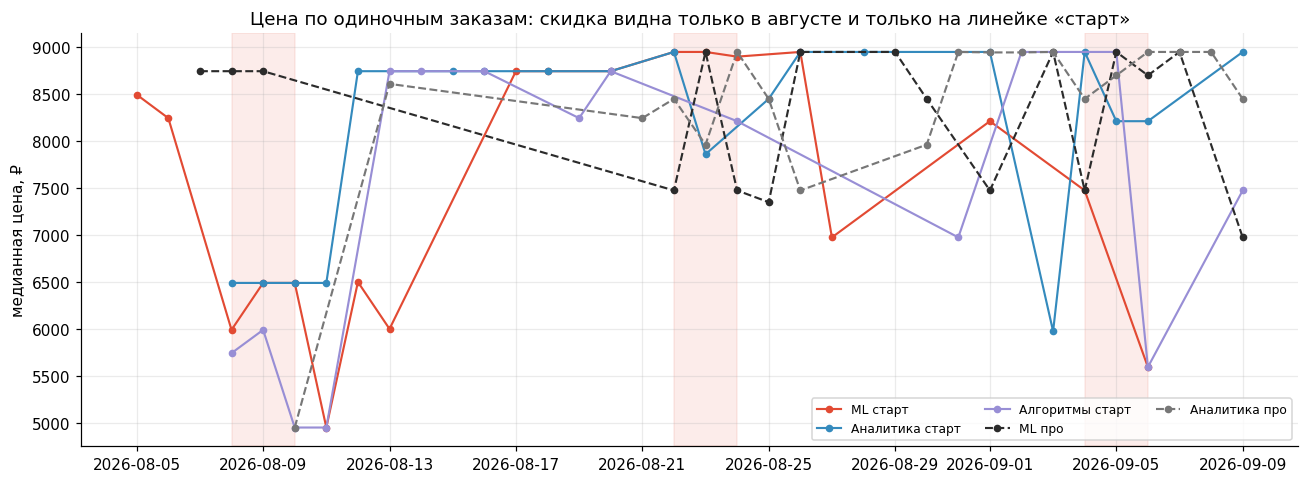

In [21]:
fig, ax = plt.subplots(figsize=(12, 4.5))
for c, color in zip(watch, ["#E24A33", "#348ABD", "#988ED5", "#2b2b2b", "#777777"]):
    s = price[c].dropna()
    ax.plot(s.index, s.values, marker="o", ms=4, lw=1.4, label=c, color=color,
            ls="--" if "про" in c else "-")
for a, b in SPIKES.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color="#E24A33", alpha=0.10)
ax.set_ylabel("медианная цена, ₽")
ax.set_title("Цена по одиночным заказам: скидка видна только в августе и только на линейке «старт»")
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

In [22]:
def window_summary(a, b):
    w = single[(single.date >= a) & (single.date <= b)]
    return pd.Series({
        "заказов": len(w),
        "медиана чека": w.revenue.median(),
        "новых курсов в окне": (prod.first_sale.between(a, pd.Timestamp(b) + pd.Timedelta("1d"))).sum(),
    })

cmp = pd.DataFrame({
    "фон (весь период)": pd.Series({
        "заказов": len(single),
        "медиана чека": single.revenue.median(),
        "новых курсов в окне": np.nan,
    }),
    **{name: window_summary(a, b) for name, (a, b) in SPIKES.items()},
})
cmp.round(0)

,фон (весь период),08–10.08,22–24.08,04–06.09
заказов,470.0,89.0,65.0,96.0
медиана чека,8450.0,6490.0,8850.0,8950.0
новых курсов в окне,NaN,4.0,1.0,0.0


Картина расходится по трём всплескам:

**08–10 августа — скидка + запуск, разделить нельзя.**
ML старт падает с 8 745 до 5 990, Аналитика старт с 7 890 до 6 490, Алгоритмы старт держится
около 4 950–5 990. При этом ML про **не дешевеет** — значит акция была адресной, на линейку
«старт». Скидка тянется примерно до 11–12 августа. В тот же день в каталоге появляются четыре
новых курса, и по внешним данным команды на 8–9 августа приходится 9 упоминаний канала.
Три фактора в одном окне — вклад каждого по отдельности из этих данных не восстанавливается.
Это не слабость решения, это его вывод.

**22–24 августа — запуск продукта.**
Цены обычные, скидки нет. 22 августа — первая продажа AI агенты, и за месяц курс набирает
второе место по выручке. Всплеск объясняется запуском, а не ценой.

**04–06 сентября — ни скидки, ни запуска.**
Медианы держатся на 8 450–8 950, новых курсов нет. 5 сентября — 16 продаж ML про по полной
цене. То есть это сдвиг спроса, а не цены.

Две конкурирующие гипотезы для третьего всплеска, обе проверяемые:
1. **сезонность** — начало учебного года; весь период 1–9 сентября держится на уровне
   180–480 тыс. ₽ в день против 30–90 тыс. в спокойном августе;
2. **внешнее размещение** — но по этому окну у нас нет собранных данных о рекламе.

Различить их можно только одним способом: собрать упоминания канала за весь период,
а не за одно окно 8–9 августа.

In [23]:
sept = full[full.date >= "2026-09-01"]
aug_calm = full[(full.date >= "2026-08-13") & (full.date <= "2026-08-21")]
print(f"спокойный август (13–21.08): медиана {rub(aug_calm.revenue.median())} в день")
print(f"сентябрь (01–09.09):         медиана {rub(sept.revenue.median())} в день")
print(f"отношение: ×{sept.revenue.median() / aug_calm.revenue.median():.1f}")

спокойный август (13–21.08): медиана 52 585 ₽ в день
сентябрь (01–09.09):         медиана 217 280 ₽ в день
отношение: ×4.1


## 7. Что ещё проверили и не нашли

Полезно показать не только находки, но и гипотезы, которые отвергнуты — это ровно то,
что организаторы называют «не маскировать отсутствие данных моделью».

In [24]:
first_purchase = order_items.groupby("student_id").ts.min().reset_index()
corr = np.corrcoef(first_purchase.student_id,
                   first_purchase.ts.astype("int64"))[0, 1]

print(f"student_id: диапазон {order_items.student_id.min()}–{order_items.student_id.max()}, "
      f"уникальных {order_items.student_id.nunique()}")
print(f"корреляция student_id с датой первой покупки: {corr:.3f}")

student_id: диапазон 1–606, уникальных 606
корреляция student_id с датой первой покупки: -0.033


`student_id` — плотный диапазон 1…606 без пропусков, но с датой первой покупки не коррелирует
вообще. Значит это не порядковый номер регистрации, а случайная перенумерация хешей.

Практический смысл: **по этим данным нельзя узнать, когда покупатель подписался на канал**,
а значит нельзя отличить «новый пользователь из рекламы» от «читатель канала с прошлого года».
Это прямо попадает в раздел «что узнать нельзя» и в обоснование того, зачем нужен tracking.

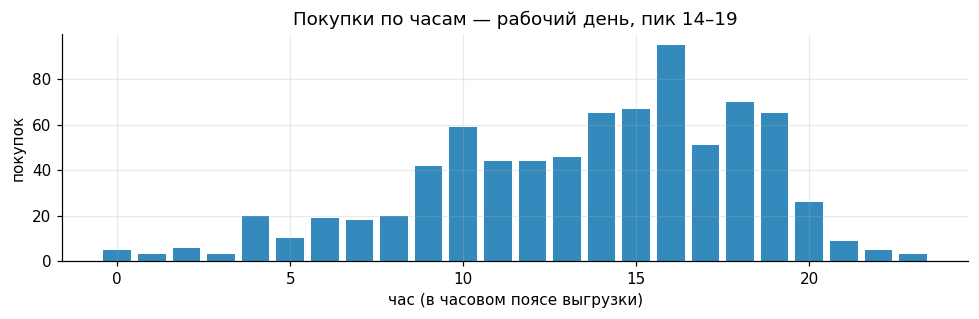

In [25]:
hourly = order_items.groupby(order_items.ts.dt.hour).size()
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(hourly.index, hourly.values, color="#348ABD")
ax.set_xlabel("час (в часовом поясе выгрузки)")
ax.set_ylabel("покупок")
ax.set_title("Покупки по часам — рабочий день, пик 14–19")
plt.tight_layout()
plt.show()

Покупки идут с 9 до 20 часов с пиком 14–19 и почти прекращаются ночью. Это согласуется с
описанием процесса из условия: оплата проходит через переписку с менеджером, то есть скорость
конверсии ограничена рабочим временем человека. Для attribution это означает, что окно между
касанием и покупкой не может быть коротким — ночное касание конвертируется только утром.

## 8. Итог: три уровня знания

Организаторы отдельным слайдом просят разделить факты, оценки и слепые зоны.
Собираем то, что получилось, именно в таком виде.

**Что мы знаем (наблюдаемо в данных)**

- 628 заказов, 606 покупателей, 5.90 млн ₽ за 04.08–10.09;
- заказ = `(student_id, timestamp)`, суммы в пакетах разнесены поровну;
- повторные покупки — около 3% покупателей и 3% выручки, они отделены от первых;
- три всплеска: 08–10.08, 22–24.08, 04–06.09;
- 08–10.08 сопровождался адресной скидкой на линейку «старт» и запуском четырёх курсов;
- 22.08 — запуск AI агенты;
- 04–06.09 прошёл без скидки и без запуска;
- выходные дают систематически более высокий уровень продаж, но с большим разбросом.

**Что мы можем оценить (модельно, с оговорками)**

- временную связь маркетинговой активности и продаж — как ассоциацию, не как причинность;
- вклад канала при заданной модели атрибуции;
- baseline-прогноз с честной валидацией.

**Что по этим данным узнать нельзя**

- когда покупатель подписался на канал и откуда пришёл;
- сколько стоило конкретное размещение — журнала размещений нет;
- какие касания были до покупки — они не логировались;
- был ли всплеск 04–06.09 вызван рекламой или сезонностью;
- является ли любая из продаж incremental.

Последние четыре пункта — это не пробел в анализе, а техническое задание на measurement
system: ровно эти события нужно начать логировать.

## 9. Выгрузка

Три файла на вход следующим этапам: attribution работает с `orders.csv`,
продуктовая аналитика — с `order_items.csv`, прогноз и ITS — с `daily.csv`.

In [26]:
orders_out = orders[["order_id", "student_id", "ts", "revenue", "n_items",
                     "courses", "seq", "is_repeat"]]
items_out = order_items[["order_id", "student_id", "ts", "course", "amount"]]
daily_out = daily.assign(is_truncated=daily.date == daily.date.max())

orders_out.to_csv(OUT / "orders.csv", index=False)
items_out.to_csv(OUT / "order_items.csv", index=False)
daily_out.to_csv(OUT / "daily.csv", index=False)

for f in ["orders.csv", "order_items.csv", "daily.csv"]:
    print(f"{f:20s} {len(pd.read_csv(OUT / f)):>5d} строк")

orders.csv             625 строк
order_items.csv        795 строк
daily.csv               38 строк


Проверка, что ничего не потеряли при агрегации: выручка по заказам должна совпасть
с суммой по исходным строкам до копейки.

In [27]:
assert abs(orders.revenue.sum() - raw.amount.sum()) < 0.01
assert len(items_out) == len(raw)
assert orders.order_id.is_unique
print("сходится:", rub(orders.revenue.sum()))

сходится: 5 904 672 ₽
